In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns 

### Data Prep

In [2]:
files = [
    "data/processed/process_ENG1.csv",
    # "data/processed/process_FRA1.csv",
    # "data/processed/process_GER1.csv",
    # "data/processed/process_ITA1.csv",
    # "data/processed/process_SPA1.csv",
]

In [3]:
dfs = []

for f in files:
    dfs.append(pd.read_csv(f))

matches_df = pd.concat(dfs, ignore_index=True)
# matches_df = matches_df.dropna()

## BREAK

In [4]:
matches_df["xg_rolling_diff"] = abs(matches_df["xg_rolling_forHomeTeam"] - matches_df["xg_rolling_forAwayTeam"])
matches_df["xg_mean_diff"] = abs(matches_df["xg_mean_forHomeTeam"] - matches_df["xg_mean_forAwayTeam"])
matches_df["xa_rolling_diff"] = abs(matches_df["xa_rolling_forHomeTeam"] - matches_df["xa_rolling_forAwayTeam"])
matches_df["xa_mean_diff"] = abs(matches_df["xa_mean_forHomeTeam"] - matches_df["xa_mean_forAwayTeam"])
matches_df["xga_rolling_diff"] = abs(matches_df["xga_rolling_forHomeTeam"] - matches_df["xga_rolling_forAwayTeam"])
matches_df["xga_mean_diff"] = abs(matches_df["xga_mean_forHomeTeam"] - matches_df["xga_mean_forAwayTeam"])
matches_df["gf_rolling_diff"] = abs(matches_df["gf_rolling_forHomeTeam"] - matches_df["gf_rolling_forAwayTeam"])
matches_df["gf_mean_diff"] = abs(matches_df["gf_mean_forHomeTeam"] - matches_df["gf_mean_forAwayTeam"])
matches_df["ga_rolling_diff"] = abs(matches_df["ga_rolling_forHomeTeam"] - matches_df["ga_rolling_forAwayTeam"])
matches_df["ga_mean_diff"] = abs(matches_df["ga_mean_forHomeTeam"] - matches_df["ga_mean_forAwayTeam"])


In [5]:
def get_predictors_basic():
    general = ["venue_code", "team_code", "day_code", "promoted", "days_since_last_game", "is_first_game"]
    attacking = ["gf", "xg", "sh", "sot", "npxg", "npxg_per_sh"]
    defense = ["int", "xga", "ga"]
    gk = ["sota", "saves", "save_pct", "psxg"]

    # add features relating to season performance (cum_pts), and result percentages (win_pct, draw_pct, loss_pct)

    base = attacking + defense + gk

    home_stats = [f"{x}_atHome_rolling" for x in base] + [f"{x}_atHome_mean" for x in base]
    away_stats = [f"{x}_atAway_rolling" for x in base] + [f"{x}_atAway_mean" for x in base]

    home_stats = [f"{x}_forHomeTeam" for x in home_stats] + [f"{x}_forAwayTeam" for x in home_stats]
    away_stats = [f"{x}_forHomeTeam" for x in away_stats] + [f"{x}_forAwayTeam" for x in away_stats]

    # Stats regardless of home/away
    overall_home = [f"{x}_rolling_forHomeTeam" for x in base] + [f"{x}_mean_forHomeTeam" for x in base]
    overall_away = [f"{x}_rolling_forAwayTeam" for x in base] + [f"{x}_mean_forAwayTeam" for x in base]

    # Seasonal performance stats
    szn_perf = ["szn_cum_pts", "szn_win_pct", "szn_draw_pct", "szn_loss_pct"]
    
    szn_perf_home_away = [f"{x}_atHome" for x in szn_perf] + [f"{x}_atAway" for x in szn_perf]
    szn_perf_final = szn_perf + szn_perf_home_away
    szn_perf_final = [f"{x}_forHomeTeam" for x in szn_perf_final] + [f"{x}_forAwayTeam" for x in szn_perf_final]


    predictors = [f"{x}_forHomeTeam" for x in general] + [f"{x}_forAwayTeam" for x in general] + home_stats + away_stats + overall_home + overall_away + szn_perf_final

    # Remove all predicotrs that contain forHomeTeam and atAway or forAwayTeam and atHome
    predictors = [col for col in predictors if not (("forHomeTeam" in col and "atAway" in col) or ("forAwayTeam" in col and "atHome" in col))]
    
    return predictors

In [6]:
cols = [
    "xg_rolling_diff",
    "xg_mean_diff",
    "xa_rolling_diff",
    "xa_mean_diff",
    "xga_rolling_diff",
    "xga_mean_diff",
    "gf_rolling_diff",
    "gf_mean_diff",
    "ga_rolling_diff",
    "ga_mean_diff"
] + get_predictors_basic()

In [7]:
X = matches_df[cols]
y = matches_df["result_code"]
y_one_hot = OneHotEncoder().fit_transform(y.values.reshape(-1, 1)).toarray()

### General Feature Selection

#### Removing Corrrelated Features

In [8]:
corr_matrix = matches_df[cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
matches_dropped = matches_df.drop(columns=to_drop)

In [9]:
len(list(corr_matrix.columns))
corr_matrix.to_csv("data/testing/corr_matrix.csv")

In [10]:
# count how many times aeriallost_rolling_home is in the upper columns
print("All columns: ", len(cols))
print("Dropped columns: ", len(to_drop))
print("Remaining columns supposedly: ", len(cols) - len(to_drop))
print("Remaining columns actually: ", len(matches_df[cols].drop(columns=to_drop).columns))

All columns:  142
Dropped columns:  17
Remaining columns supposedly:  125
Remaining columns actually:  125


#### Feature Importance Using Simple Regression

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_one_hot = OneHotEncoder().fit_transform(y.values.reshape(-1, 1)).toarray()
y_std = scaler.fit_transform(y_one_hot)

N = X_scaled.shape[0]
w = np.dot(X_scaled.T, y_one_hot) / N

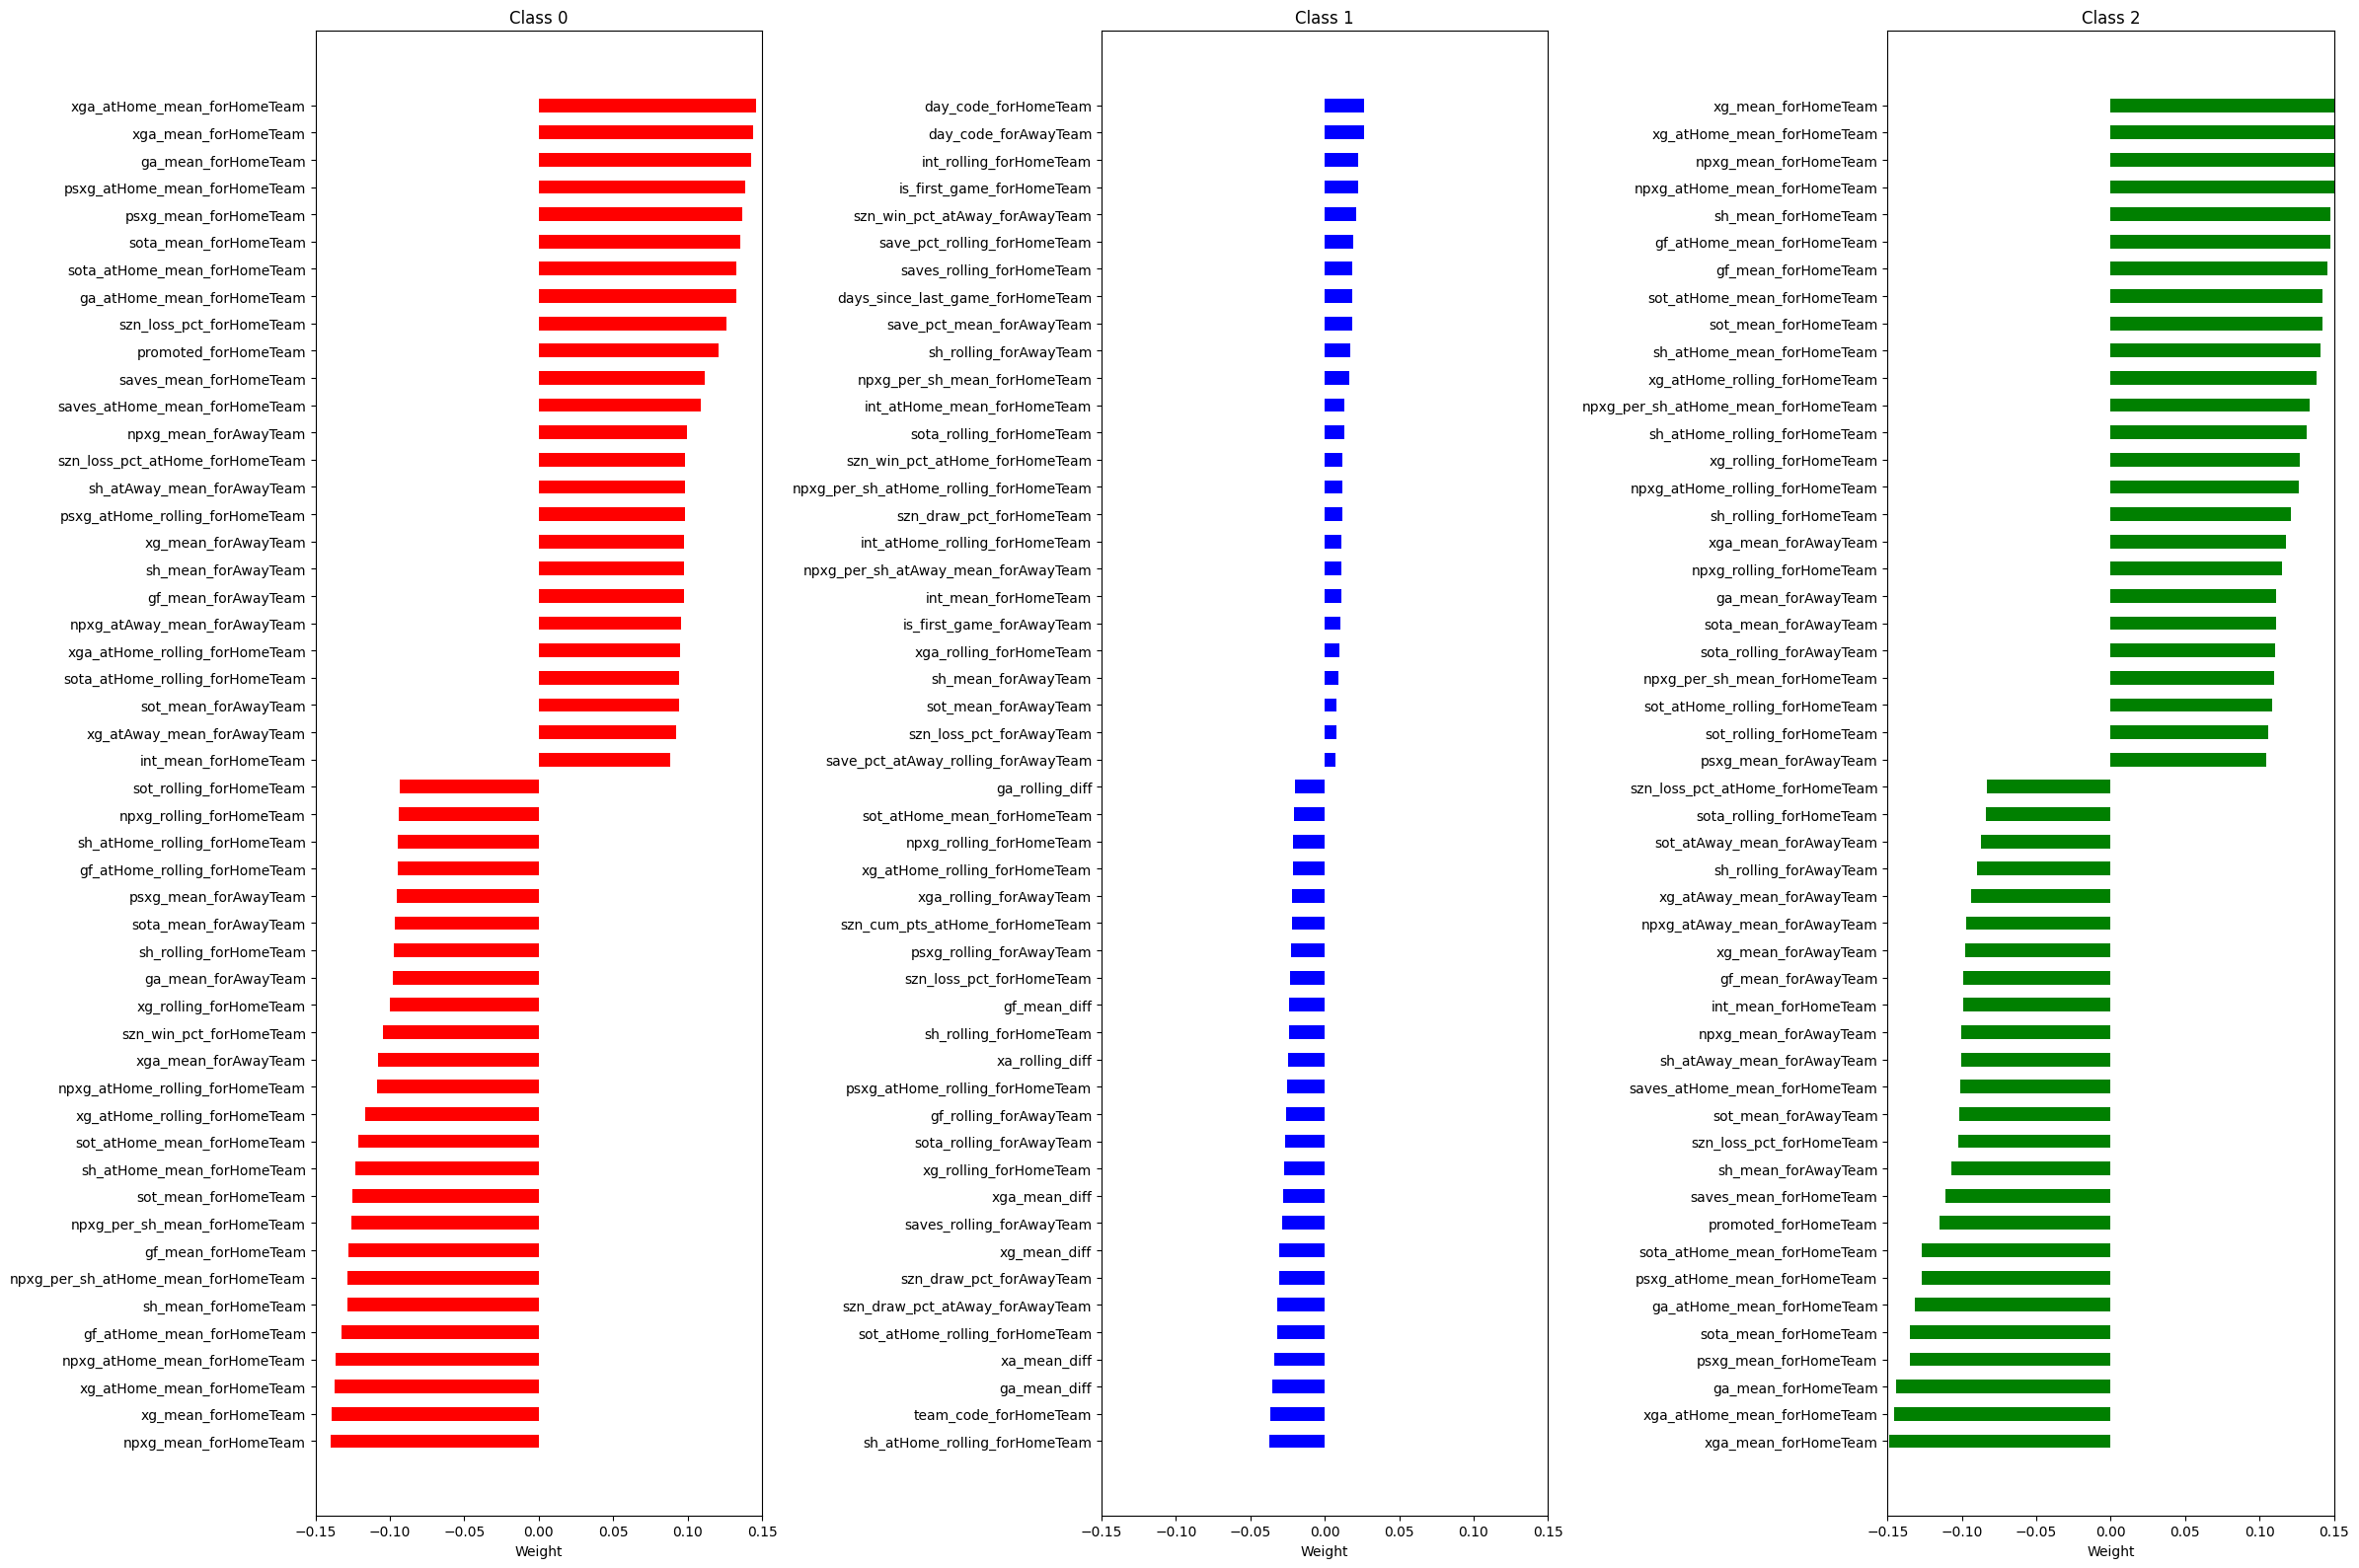

In [12]:
D, C = w.shape

fig, axes = plt.subplots(1, C, figsize=(24, 16))

colors = ["red", "blue", "green"]

feature_importances = dict()

for c in range(C):
    ax = axes[c]

    w_class = w[:, c]

    # sort the weights
    sorted_indices = np.argsort(w_class)[::-1]
    sorted_w = w_class[sorted_indices]
    sorted_features = X.columns[sorted_indices]

    # if c != 1:
    #     # Only keep rel_cols features
    #     rel_cols_indices = [i for i, feature in enumerate(sorted_features) if feature in rel_cols]
    #     rel_cols_sorted_indices = sorted_indices[rel_cols_indices]
    #     rel_cols_sorted_w = sorted_w[rel_cols_indices]
    #     rel_cols_sorted_features = sorted_features[rel_cols_indices]

    #     # Plot features
    #     ax.barh(rel_cols_sorted_features, rel_cols_sorted_w, color=colors[c], height=0.5)
    #     ax.set_title(f"Class {c}")
    #     ax.set_xlabel("Weight")
    #     ax.invert_yaxis()
    # else:
    #     # take top 25 and bottom 25 features and weights
    #     selected_features = np.concatenate([sorted_features[:25], sorted_features[-25:]])
    #     selected_w = np.concatenate([sorted_w[:25], sorted_w[-25:]])
        
    #     # Create horizontal bar plot
    #     ax.barh(selected_features, selected_w, color=colors[c], height=0.5)
    #     ax.set_title(f"Class {c}")
    #     ax.set_xlabel("Weight")
    #     ax.invert_yaxis()

    # Only keep rel_cols features
    # rel_cols_indices = [i for i, feature in enumerate(sorted_features) if feature in rel_cols]
    # rel_cols_indices = [i for i, feature in enumerate(sorted_features) if "win_pct" in feature or "draw_pct" in feature or "loss_pct" in feature or "cum_pts" in feature]
    # rel_cols_sorted_indices = sorted_indices[rel_cols_indices]
    # rel_cols_sorted_w = sorted_w[rel_cols_indices]
    # rel_cols_sorted_features = sorted_features[rel_cols_indices]

    # # Plot features
    # ax.barh(rel_cols_sorted_features, rel_cols_sorted_w, color=colors[c], height=0.5)
    # ax.set_title(f"Class {c}")
    # ax.set_xlabel("Weight")
    # ax.invert_yaxis()

    # # take top 25 and bottom 25 features and weights
    selected_features = np.concatenate([sorted_features[:25], sorted_features[-25:]])
    selected_w = np.concatenate([sorted_w[:25], sorted_w[-25:]])
        
    # Create horizontal bar plot
    ax.barh(selected_features, selected_w, color=colors[c], height=0.5)
    ax.set_title(f"Class {c}")
    ax.set_xlabel("Weight")
    ax.invert_yaxis()
    ax.set_xlim(-0.15, 0.15)


    for feat, coef in zip(sorted_features, sorted_w):
        if feat in feature_importances:
            feature_importances[feat].append(coef)
        else:
            feature_importances[feat] = [coef]

plt.tight_layout()
plt.show()

In [13]:
# Mean absolute feature importance
mean_fi = {feat: np.mean([abs(x) for x in coefs]) for feat, coefs in feature_importances.items()}
sorted_mean_fi = sorted(mean_fi.items(), key=lambda x: x[1], reverse=True)

# Feature importance variability
var_fi = {feat: np.std([abs(x) for x in coefs]) for feat, coefs in feature_importances.items()}
sorted_var_fi = sorted(var_fi.items(), key=lambda x: x[1], reverse=True)

mean_mean_fi = np.mean([i for i in mean_fi.values()])
mean_var_fi = np.mean([i for i in var_fi.values()])

selected_features = [feat for feat, _ in mean_fi.items() if mean_fi[feat] > mean_mean_fi and var_fi[feat] > mean_var_fi]

#### Import and setup models

In [ ]:
from models.classification.RandomForestClassifier import RFC
from models.classification.XGBClassifier import XGBC
from models.classification.LR import LRWrapper
from models.classification.SVC import SVCWrapper

In [15]:
# Init models
rfc = RFC()
xgbc = XGBC()
lr_1v1 = LRWrapper()
lr_1vR = LRWrapper(one_vs_rest=True)
svc_1v1 = SVCWrapper()
svc_1vR = SVCWrapper(one_vs_rest=True)

In [16]:
labels = np.array([0, 1, 2])
targets = np.array(["Away Win", "Draw", "Home Win"])

In [17]:
features = cols

matches_df_train, matches_df_test = train_test_split(matches_df, test_size=0.25, random_state=42, stratify=None)

#### RF

In [18]:
rfc.train(matches_df_train, features)

In [19]:
rfc_results = rfc.evaluate_model(matches_df_test, features)

In [20]:
correct_predictions_rf = rfc_results[rfc_results["Actual_Result"] == rfc_results["Predicted_Result"]]
accuracy_rf = len(correct_predictions_rf) / len(rfc_results)

classification_report_rf = classification_report(rfc_results["Actual_Result"], rfc_results["Predicted_Result"], zero_division=0, labels=labels, target_names=targets, output_dict=True)

In [21]:
print("Random Forest Classifier Accuracy: ", accuracy_rf)

Random Forest Classifier Accuracy:  0.5734597156398105


#### XGBC

In [22]:
xgbc.train(matches_df_train, features)

In [23]:
xgbc_results = xgbc.evaluate_model(matches_df_test, features)

In [24]:
correct_predictions_xgbc = xgbc_results[xgbc_results["Actual_Result"] == xgbc_results["Predicted_Result"]]
accuracy_xgbc = len(correct_predictions_xgbc) / len(xgbc_results)

classification_report_xgbc = classification_report(xgbc_results["Actual_Result"], xgbc_results["Predicted_Result"], zero_division=0, labels=labels, target_names=targets, output_dict=True)

In [25]:
print("XGBoost Classifier Accuracy: ", accuracy_xgbc)

XGBoost Classifier Accuracy:  0.46919431279620855


#### Try on Multinomial

In [26]:
lr_1v1.train(matches_df_train, features)
lr_1vR.train(matches_df_train, features)

In [27]:
lr_1v1_results = lr_1v1.evaluate_model(matches_df_test, features)
lr_1vR_results = lr_1vR.evaluate_model(matches_df_test, features)

In [28]:
correct_predictions_lr_1v1 = lr_1v1_results[lr_1v1_results["Actual_Result"] == lr_1v1_results["Predicted_Result"]]
accuracy_lr_1v1 = len(correct_predictions_lr_1v1) / len(lr_1v1_results)

correct_predictions_lr_1vR = lr_1vR_results[lr_1vR_results["Actual_Result"] == lr_1vR_results["Predicted_Result"]]
accuracy_lr_1vR = len(correct_predictions_lr_1vR) / len(lr_1vR_results)

classification_report_lr_1v1 = classification_report(lr_1v1_results["Actual_Result"], lr_1v1_results["Predicted_Result"], zero_division=0, labels=labels, target_names=targets, output_dict=True)
classification_report_lr_1vR = classification_report(lr_1vR_results["Actual_Result"], lr_1vR_results["Predicted_Result"], zero_division=0, labels=labels, target_names=targets, output_dict=True)

In [29]:
print("Logistc Regression 1v1 Accuracy: ", accuracy_lr_1v1)

Logistc Regression 1v1 Accuracy:  0.5260663507109005


In [30]:
print("Logistc Regression 1vR Accuracy: ", accuracy_lr_1vR)

Logistc Regression 1vR Accuracy:  0.5213270142180095


#### Try on SVM

In [31]:
svc_1v1.train(matches_df_train, features)
svc_1vR.train(matches_df_train, features)

In [32]:
svc_1v1_results = svc_1v1.evaluate_model(matches_df_test, features)
svc_1vR_results = svc_1vR.evaluate_model(matches_df_test, features)

In [33]:
correct_predictions_svc_1v1 = svc_1v1_results[svc_1v1_results["Actual_Result"] == svc_1v1_results["Predicted_Result"]]
accuracy_svc_1v1 = len(correct_predictions_svc_1v1) / len(svc_1v1_results)

correct_predictions_svc_1vR = svc_1vR_results[svc_1vR_results["Actual_Result"] == svc_1vR_results["Predicted_Result"]]
accuracy_svc_1vR = len(correct_predictions_svc_1vR) / len(svc_1vR_results)

classification_report_svc_1v1 = classification_report(svc_1v1_results["Actual_Result"], svc_1v1_results["Predicted_Result"], zero_division=0, labels=labels, target_names=targets, output_dict=True)
classification_report_svc_1vR = classification_report(svc_1vR_results["Actual_Result"], svc_1vR_results["Predicted_Result"], zero_division=0, labels=labels, target_names=targets, output_dict=True)

In [34]:
print("SVC 1v1 Accuracy: ", accuracy_svc_1v1)

SVC 1v1 Accuracy:  0.4881516587677725


In [35]:
print("SVC 1vR Accuracy: ", accuracy_svc_1vR)

SVC 1vR Accuracy:  0.5450236966824644


#### Try with Soft voting

#### Analyzing the results

In [36]:
# find % of home wins, draws and away wins in y (2 is home win, 1 is draw, 0 is away win)
result_distribution = matches_df["result_code"].value_counts(normalize=True).to_dict()

# replace 2 by "Home Win", 1 by "Draw", 0 by "Away Win" in the keys of result_distribution
result_distribution = {("Home Win" if k == 2 else "Draw" if k == 1 else "Away Win"): v for k, v in result_distribution.items()}

print("Result Distribution: ", result_distribution)

Result Distribution:  {'Home Win': 0.4328180737217598, 'Away Win': 0.3258026159334126, 'Draw': 0.2413793103448276}


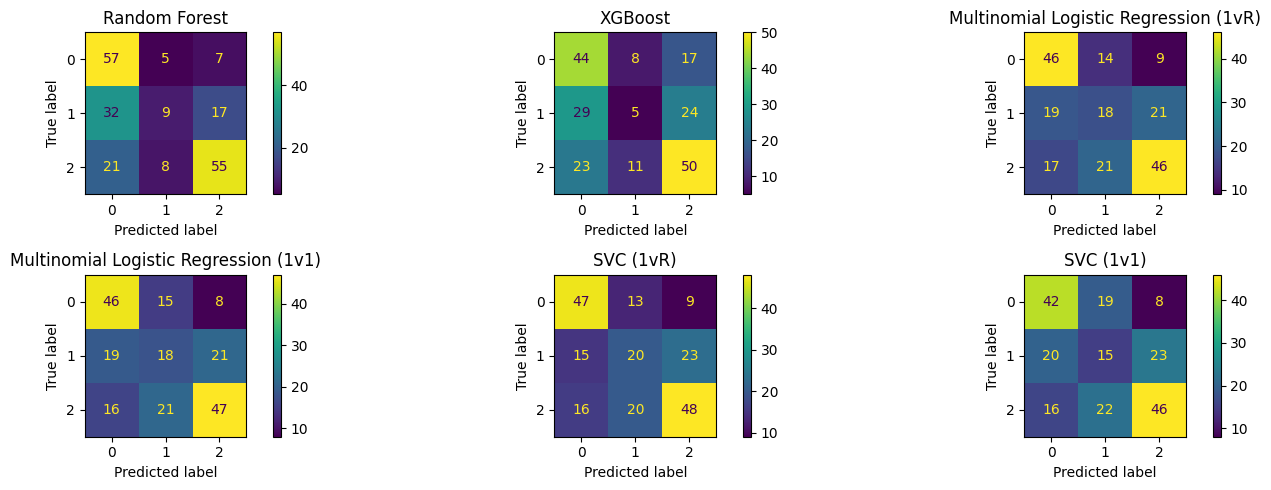

In [37]:
# Confusion matrix for RF
cm_rf = confusion_matrix(rfc_results["Actual_Result"], rfc_results["Predicted_Result"])
disp_rf = ConfusionMatrixDisplay(cm_rf)

# Confusion matrix for XGBC
cm_xgb = confusion_matrix(xgbc_results["Actual_Result"], xgbc_results["Predicted_Result"])
disp_xgb = ConfusionMatrixDisplay(cm_xgb)

# Confusion matrix for Multinomial Logistic Regression
cm_mc_1vR = confusion_matrix(lr_1vR_results["Actual_Result"], lr_1vR_results["Predicted_Result"])
disp_mc_1vR = ConfusionMatrixDisplay(cm_mc_1vR)

cm_mc_1v1 = confusion_matrix(lr_1v1_results["Actual_Result"], lr_1v1_results["Predicted_Result"])
disp_mc_1v1 = ConfusionMatrixDisplay(cm_mc_1v1)

# Confusion matrix for SVC
cm_svc_1vR = confusion_matrix(svc_1vR_results["Actual_Result"], svc_1vR_results["Predicted_Result"])
disp_svc_1vR = ConfusionMatrixDisplay(cm_svc_1vR)

cm_svc_1v1 = confusion_matrix(svc_1v1_results["Actual_Result"], svc_1v1_results["Predicted_Result"])
disp_svc_1v1 = ConfusionMatrixDisplay(cm_svc_1v1)

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 5))

# Plot each confusion matrix
disp_rf.plot(ax=axes[0, 0])
disp_rf.ax_.set_title("Random Forest")

disp_xgb.plot(ax=axes[0, 1])
disp_xgb.ax_.set_title("XGBoost")

disp_mc_1vR.plot(ax=axes[0, 2])
disp_mc_1vR.ax_.set_title("Multinomial Logistic Regression (1vR)")

disp_mc_1v1.plot(ax=axes[1, 0])
disp_mc_1v1.ax_.set_title("Multinomial Logistic Regression (1v1)")

disp_svc_1vR.plot(ax=axes[1, 1])
disp_svc_1vR.ax_.set_title("SVC (1vR)")

disp_svc_1v1.plot(ax=axes[1, 2])
disp_svc_1v1.ax_.set_title("SVC (1v1)")

plt.tight_layout()
plt.show()


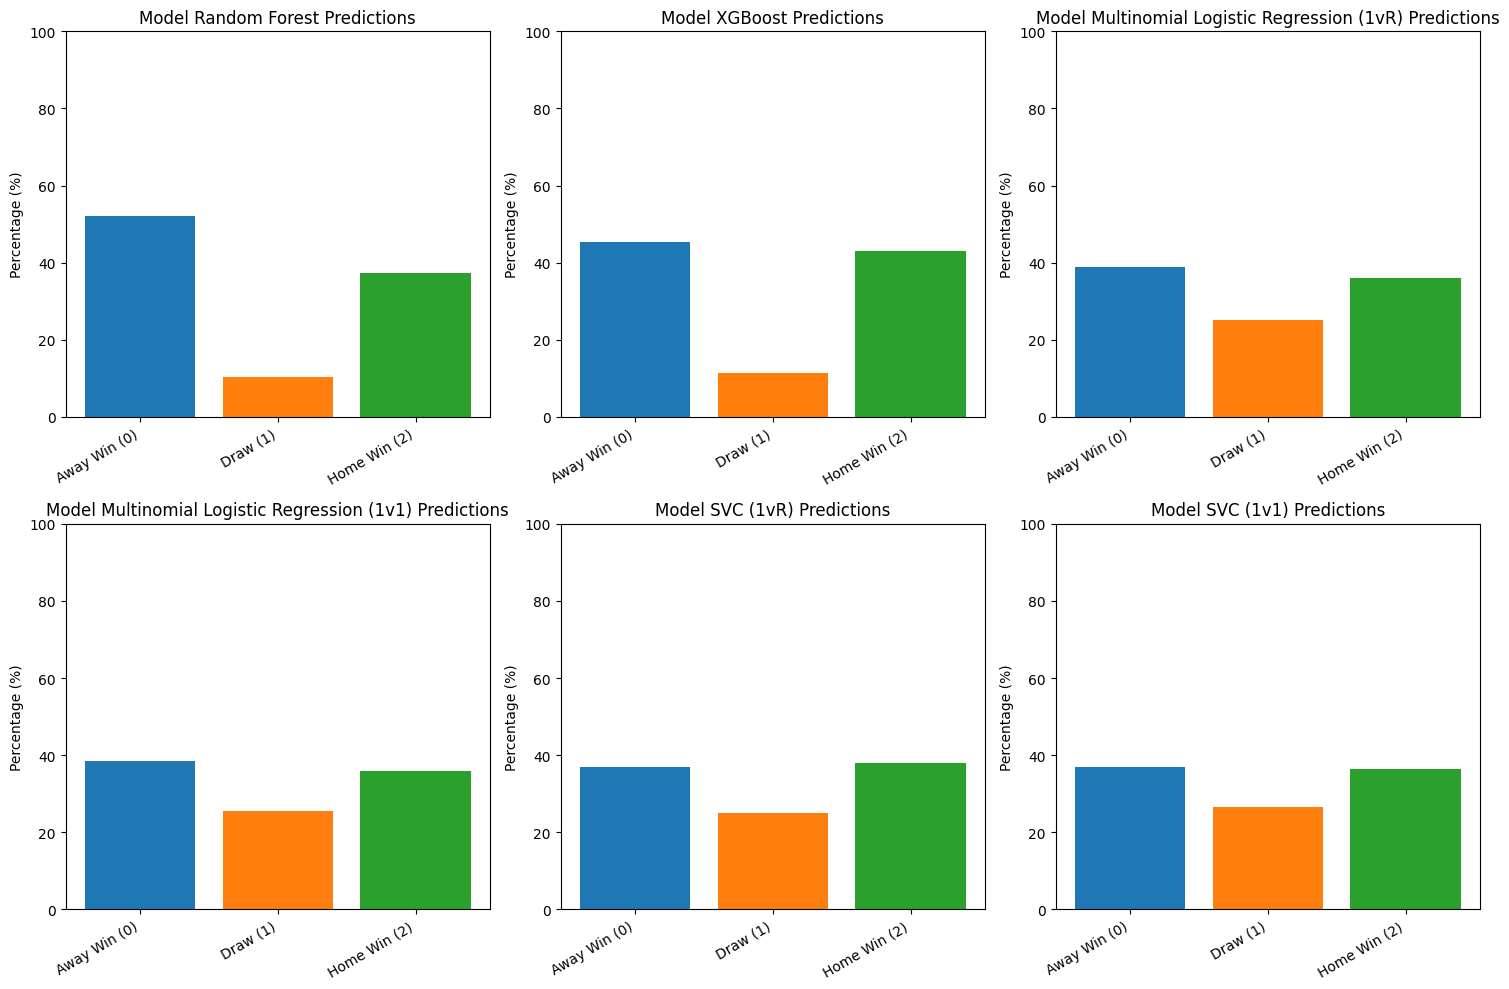

In [38]:
predictions_list = [rfc_results["Predicted_Result"], xgbc_results["Predicted_Result"], lr_1vR_results["Predicted_Result"], lr_1v1_results["Predicted_Result"], svc_1vR_results["Predicted_Result"], svc_1v1_results["Predicted_Result"]]
models = ['Random Forest', 'XGBoost', 'Multinomial Logistic Regression (1vR)', 'Multinomial Logistic Regression (1v1)', 'SVC (1vR)', 'SVC (1v1)']
classes = ['Away Win (0)', 'Draw (1)', 'Home Win (2)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 3 columns

for i, ax in enumerate(axes.flat):
    predictions = predictions_list[i]
    
    # Count occurrences of each class
    unique, counts = np.unique(predictions, return_counts=True)
    
    # Convert to percentage
    percentages = counts / counts.sum() * 100
    
    # Plot the bar chart
    ax.bar(unique, percentages, color=colors)
    
    # Formatting
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(classes, rotation=30, ha="right")
    ax.set_ylim(0, 100)
    ax.set_ylabel("Percentage (%)")
    ax.set_title(f"Model {models[i]} Predictions")

plt.tight_layout()
plt.show()

In [39]:
type(classification_report_rf)

dict

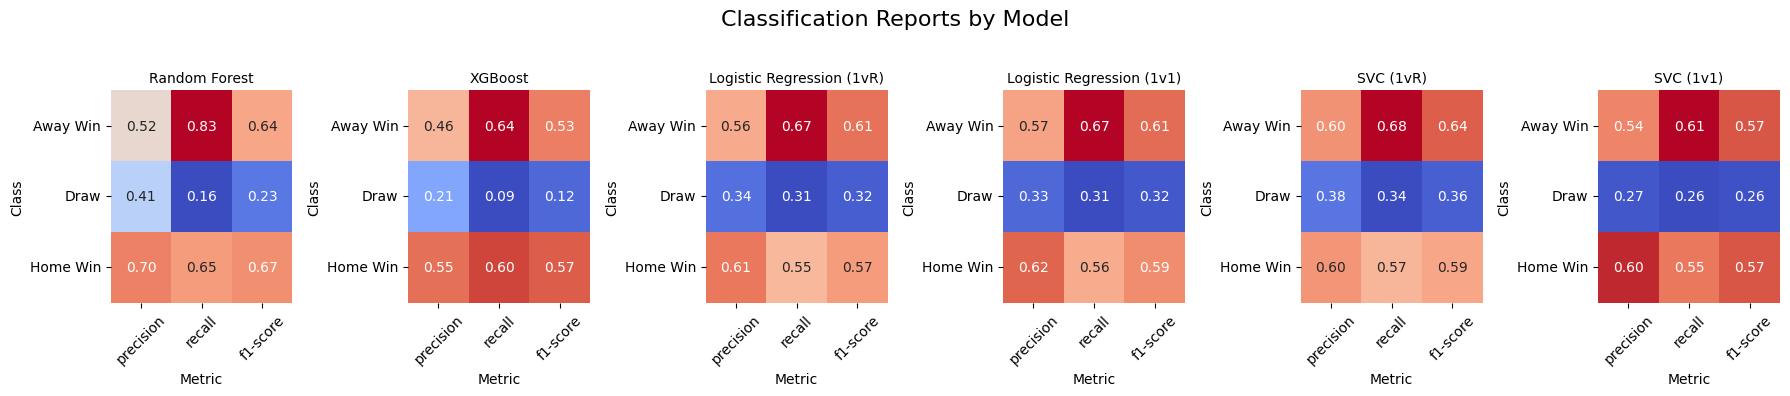

In [40]:
# Create a DataFrame to store the accuracies and the accuracies per class
all_reports = [
    classification_report_rf, classification_report_xgbc, classification_report_lr_1vR, classification_report_lr_1v1, classification_report_svc_1vR, classification_report_svc_1v1
]

models = [
    "Random Forest",
    "XGBoost",
    "Logistic Regression (1vR)",
    "Logistic Regression (1v1)",
    "SVC (1vR)",
    "SVC (1v1)"
]

fig, axes = plt.subplots(1, len(models), figsize=(18, 4))
# axes = axes.flatten()

for ax, model_name, report in zip(axes, models, all_reports):
    # Convert report dict to DataFrame and select metrics
    
    df = pd.DataFrame(report).transpose()
    df = df[["precision", "recall", "f1-score"]]
    
    # Remove 'accuracy', 'macro avg', 'weighted avg' if you only want class-specific rows
    df = df.drop(["accuracy", "macro avg", "weighted avg"], errors="ignore")

    # Plot heatmap
    sns.heatmap(df, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, cbar=False)
    ax.set_title(model_name, fontsize=10)
    ax.set_ylabel("Class")
    ax.set_xlabel("Metric")
    ax.tick_params(axis='x', labelrotation=45)
    ax.tick_params(axis='y', labelrotation=0)

plt.suptitle("Classification Reports by Model", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
plt.show()

In [41]:
f1_df = pd.DataFrame(
    {
        "Model": models,
        "F1 Score (Away Win)": [report["Away Win"]["f1-score"] for report in all_reports],
        "F1 Score (Draw)": [report["Draw"]["f1-score"] for report in all_reports],
        "F1 Score (Home Win)": [report["Home Win"]["f1-score"] for report in all_reports],
        "Overall F1 Score (Avg)": [report["macro avg"]["f1-score"] for report in all_reports],
        "Overall F1 Score (Weighted)": [report["weighted avg"]["f1-score"] for report in all_reports],
    }
).set_index("Model")

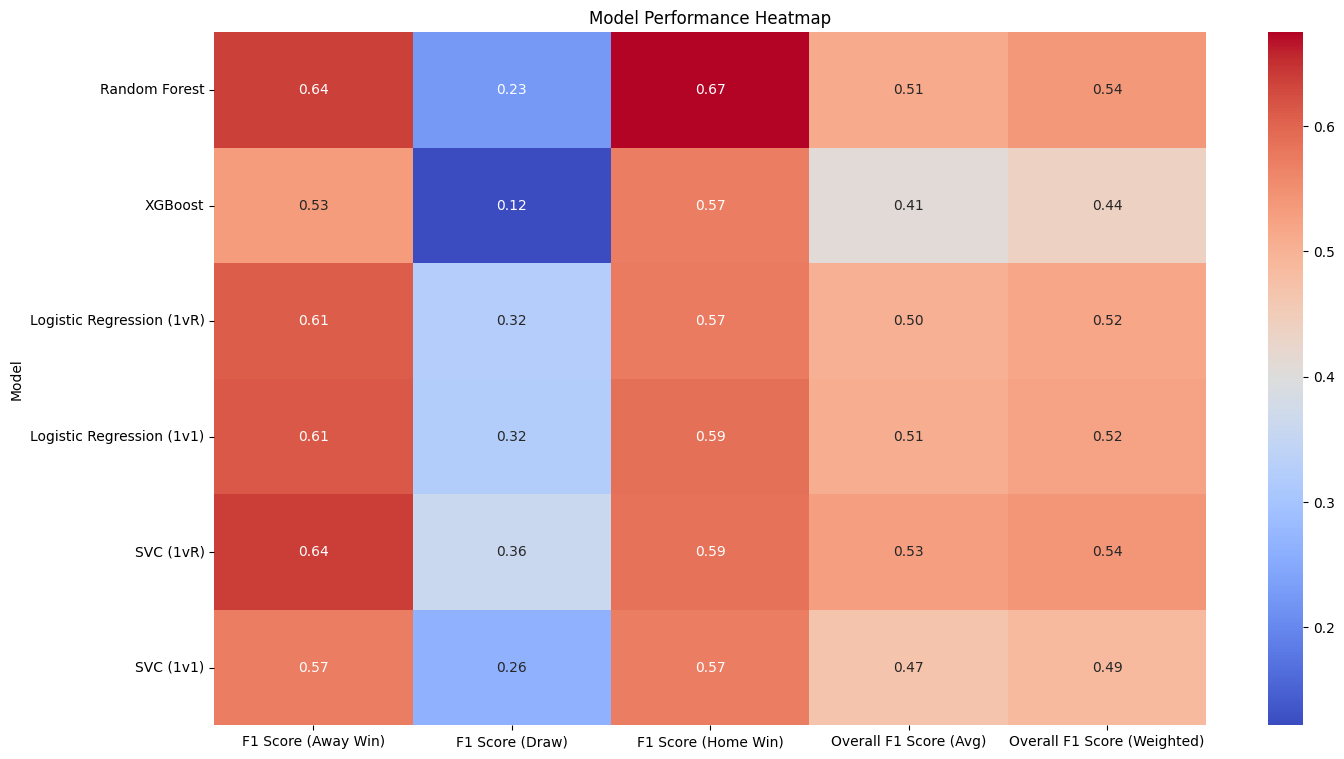

In [42]:
plt.figure(figsize=(16, 9))
sns.heatmap(f1_df, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title("Model Performance Heatmap")
plt.show()

In [43]:
f1_df

,F1 Score (Away Win),F1 Score (Draw),F1 Score (Home Win),Overall F1 Score (Avg),Overall F1 Score (Weighted)
Model,,,,,
Random Forest,0.636872,0.225000,0.674847,0.512239,0.538774
XGBoost,0.533333,0.121951,0.571429,0.408904,0.435418
Logistic Regression (1vR),0.609272,0.324324,0.575000,0.502865,0.517301
Logistic Regression (1v1),0.613333,0.321429,0.587500,0.507421,0.522810
SVC (1vR),0.639456,0.360360,0.585366,0.528394,0.541204
SVC (1v1),0.571429,0.263158,0.571429,0.468672,0.486691


In [44]:
print(f"Random Forest:\n{cm_rf}")
print(f"XGB:\n{cm_xgb}")
print(f"Multiclass Regression 1vR:\n{cm_mc_1vR}")
print(f"Multiclass Regression 1v1:\n{cm_mc_1v1}")
print(f"SVC 1vR:\n{cm_svc_1vR}")
print(f"SVC 1v1:\n{cm_svc_1v1}")

Random Forest:
[[57  5  7]
 [32  9 17]
 [21  8 55]]
XGB:
[[44  8 17]
 [29  5 24]
 [23 11 50]]
Multiclass Regression 1vR:
[[46 14  9]
 [19 18 21]
 [17 21 46]]
Multiclass Regression 1v1:
[[46 15  8]
 [19 18 21]
 [16 21 47]]
SVC 1vR:
[[47 13  9]
 [15 20 23]
 [16 20 48]]
SVC 1v1:
[[42 19  8]
 [20 15 23]
 [16 22 46]]


In [63]:
accuracy_df = pd.DataFrame(
    {
        "Model": models,
        "Accuracy": [
            accuracy_rf,
            accuracy_xgbc,
            accuracy_lr_1vR,
            accuracy_lr_1v1,
            accuracy_svc_1vR,
            accuracy_svc_1v1,
        ],
    }
)

In [64]:
accuracy_df

,Model,Accuracy
0,Random Forest,0.573460
1,XGBoost,0.469194
2,Logistic Regression (1vR),0.521327
3,Logistic Regression (1v1),0.526066
4,SVC (1vR),0.545024
5,SVC (1v1),0.488152


#### Try soft voting

In [58]:
# Average probabilites from all models (soft voting)
model_results = [rfc_results, xgbc_results, lr_1vR_results, lr_1v1_results, svc_1vR_results, svc_1v1_results]

home_win_probs = []
draw_probs = []
away_win_probs = []

for model_res in model_results:
    home_win_probs.append(model_res['Prob_Home_Win'] / 100)  # Normalize to [0, 1]
    draw_probs.append(model_res['Prob_Draw'] / 100)          # Normalize to [0, 1]
    away_win_probs.append(model_res['Prob_Away_Win'] / 100)  # Normalize to [0, 1]

avg_home_win_probs = np.mean(home_win_probs, axis=0)
avg_draw_probs = np.mean(draw_probs, axis=0)
avg_away_win_probs = np.mean(away_win_probs, axis=0)

total_probs = avg_home_win_probs + avg_draw_probs + avg_away_win_probs
avg_home_win_probs /= total_probs
avg_draw_probs /= total_probs
avg_away_win_probs /= total_probs

final_probs_df = pd.DataFrame({
    'Prob_Home_Win': (avg_home_win_probs * 100).round(1),  # Convert back to percentage
    'Prob_Draw': (avg_draw_probs * 100).round(1),          # Convert back to percentage
    'Prob_Away_Win': (avg_away_win_probs * 100).round(1),  # Convert back to percentage
})

final_probs_df['Predicted_Result'] = np.argmax(
    np.stack([avg_away_win_probs, avg_draw_probs, avg_home_win_probs], axis=1),
    axis=1
)

final_probs_df['Actual_Result'] = rfc_results['Actual_Result'].reset_index(drop=True)

In [59]:
# Get accuracy for soft voting
correct_predictions_soft_voting = final_probs_df[final_probs_df["Actual_Result"] == final_probs_df["Predicted_Result"]]
accuracy_soft_voting = len(correct_predictions_soft_voting) / len(final_probs_df)

classification_report_soft_voting = classification_report(final_probs_df["Actual_Result"], final_probs_df["Predicted_Result"], zero_division=0, labels=labels, target_names=targets, output_dict=True)

In [60]:
print("Soft voting Accuracy: ", accuracy_soft_voting)

Soft voting Accuracy:  0.5308056872037915


In [62]:
# Prediction distribution for soft voting
pct_home_wins = len(final_probs_df[final_probs_df["Predicted_Result"] == 2]) / len(final_probs_df) * 100
pct_draws = len(final_probs_df[final_probs_df["Predicted_Result"] == 1]) / len(final_probs_df) * 100
pct_away_wins = len(final_probs_df[final_probs_df["Predicted_Result"] == 0]) / len(final_probs_df) * 100

print("Percentage of Home Wins predicted: ", pct_home_wins)
print("Percentage of Draws predicted: ", pct_draws)
print("Percentage of Away Wins predicted: ", pct_away_wins)


Percentage of Home Wins predicted:  36.96682464454976
Percentage of Draws predicted:  22.748815165876778
Percentage of Away Wins predicted:  40.28436018957346
